# Galacticus SED Unit Check

Visual inspection of galaxy SEDs from the Galacticus 4 deg² mock to confirm units (f_nu vs f_lambda).

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table

HDF5_PATH = '/Users/np274/data/Roman/galacticus_4deg2_mock/galacticus_FOV_EVERY100_sub_1.hdf5'
FITS_PATH = '/Users/np274/data/Roman/galacticus_4deg2_mock/Euclid_Roman_4deg2_radec.fits'

# Wavelength grid (implicit, not stored in HDF5)
wl_ang = np.linspace(2000, 40000, 19001)  # Angstroms
wl_um = wl_ang / 1e4  # microns

In [2]:
# Load FITS index for metadata (magnitudes, redshifts)
cat = Table.read(FITS_PATH)
# Filter to SIM=1 (the one in the HDF5 file)
mask_sim1 = cat['SIM'] == 1
cat1 = cat[mask_sim1]
print(f'SIM=1 sources: {len(cat1)}')
print(f'F158 mag range: {cat1["mag_F158_Av1.6523"].min():.1f} to {cat1["mag_F158_Av1.6523"].max():.1f}')
print(f'Redshift range: {cat1["Z"].min():.2f} to {cat1["Z"].max():.2f}')

SIM=1 sources: 29956
F158 mag range: 15.3 to 35.2
Redshift range: 0.04 to 8.67


In [3]:
# Load a handful of SEDs at different magnitudes and redshifts
# Pick bright sources for clear signal
bright = cat1[cat1['mag_F158_Av1.6523'] < 22]
print(f'Bright sources (F158 < 22): {len(bright)}')

# Pick ~8 representative sources spanning redshift range
z_sorted = np.argsort(bright['Z'])
pick_idx = np.linspace(0, len(z_sorted)-1, 8, dtype=int)
selected = bright[z_sorted[pick_idx]]

for row in selected:
    print(f"  IDX={row['IDX']:5d}  z={row['Z']:.3f}  F158={row['mag_F158_Av1.6523']:.2f}")

Bright sources (F158 < 22): 688
  IDX=25044  z=0.042  F158=20.02
  IDX=24252  z=0.269  F158=20.95
  IDX=27310  z=0.387  F158=20.97
  IDX=23057  z=0.493  F158=20.15
  IDX= 9678  z=0.668  F158=21.77
  IDX=19339  z=0.786  F158=21.45
  IDX=17872  z=1.021  F158=21.87
  IDX=21885  z=2.444  F158=21.90


In [4]:
# Load the SEDs from HDF5
with h5py.File(HDF5_PATH, 'r') as f:
    sed_key = [k for k in f['Outputs'].keys() if 'SED' in k][0]
    print(f'SED key: {sed_key}')
    # HDF5 requires indices in increasing order
    idx = np.array(selected['IDX'])
    sort_order = np.argsort(idx)
    unsort_order = np.argsort(sort_order)
    seds = f[f'Outputs/{sed_key}'][idx[sort_order], :][unsort_order]  # shape (8, 19001)

print(f'SED shape: {seds.shape}')
print(f'SED dtype: {seds.dtype}')
print(f'SED range: {seds.min():.3e} to {seds.max():.3e}')

SED key: SED:observed:dust:Av1.6523
SED shape: (8, 19001)
SED dtype: float64
SED range: 2.917e-06 to 1.120e+05


## Raw SEDs

If units are **f_nu**: spectra should be relatively flat (in nu*f_nu or lambda*f_lambda sense), rising toward red.

If units are **f_lambda**: spectra would typically decline toward red for most galaxy types.

## Reference: Known Templates in f_lambda and f_nu

Plot the bundled KC96 and G0V templates (which have known units from PYSYN_CDBS) in both representations. This gives us a visual reference for what galaxy/stellar SEDs "should" look like in each convention.

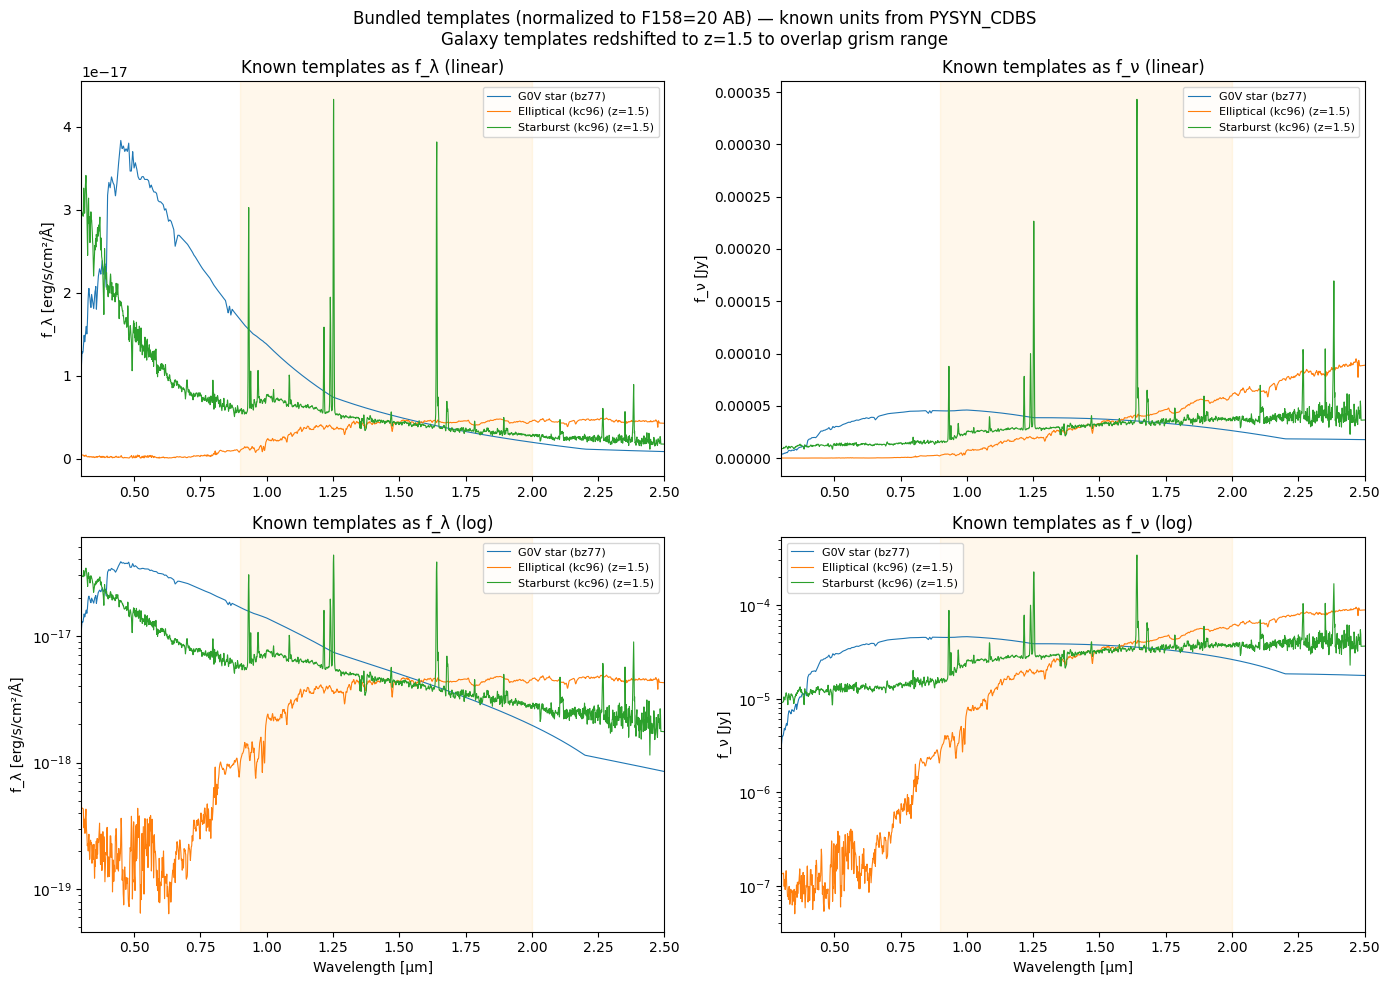

In [5]:
from synphot import SourceSpectrum, units as syn_units
from roman_disperser import refdata
import astropy.units as u

# Load the three bundled templates
templates = {
    'G0V star (bz77)': refdata.get_template('g0v'),
    'Elliptical (kc96)': refdata.get_template('kc96_elliptical'),
    'Starburst (kc96)': refdata.get_template('kc96_starb1'),
}

# KC96 templates are rest-frame ~1235-9935 Å, too blue for F158.
# Redshift the galaxy templates to z=1.5 so they overlap the grism range,
# then normalize. Star template already covers F158.
bp_ref = refdata.get_f158_band()

templates_plot = {}
for name, sp in templates.items():
    if 'kc96' in name.lower():
        sp_z = SourceSpectrum(sp.model, z=1.5)
        sp_z = sp_z.normalize(20.0 * u.ABmag, band=bp_ref, vegaspec=None)
        templates_plot[f'{name} (z=1.5)'] = sp_z
    else:
        sp_norm = sp.normalize(20.0 * u.ABmag, band=bp_ref, vegaspec=None)
        templates_plot[name] = sp_norm

# Evaluate on a common wavelength grid
wl_eval = np.linspace(3000, 25000, 5000) * u.AA
wl_eval_um = wl_eval.to(u.um).value

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['C0', 'C1', 'C2']

# Top left: f_lambda (linear)
ax = axes[0, 0]
for (name, sp), c in zip(templates_plot.items(), colors):
    flam = sp(wl_eval, flux_unit=syn_units.FLAM).value
    ax.plot(wl_eval_um, flam, lw=0.8, color=c, label=name)
ax.set_ylabel('f_λ [erg/s/cm²/Å]')
ax.set_title('Known templates as f_λ (linear)')
ax.axvspan(0.9, 2.0, alpha=0.08, color='orange')
ax.legend(fontsize=8)
ax.set_xlim(0.3, 2.5)

# Top right: f_nu (linear)
ax = axes[0, 1]
for (name, sp), c in zip(templates_plot.items(), colors):
    fnu = sp(wl_eval, flux_unit=u.Jy).value
    ax.plot(wl_eval_um, fnu, lw=0.8, color=c, label=name)
ax.set_ylabel('f_ν [Jy]')
ax.set_title('Known templates as f_ν (linear)')
ax.axvspan(0.9, 2.0, alpha=0.08, color='orange')
ax.legend(fontsize=8)
ax.set_xlim(0.3, 2.5)

# Bottom left: f_lambda (log)
ax = axes[1, 0]
for (name, sp), c in zip(templates_plot.items(), colors):
    flam = sp(wl_eval, flux_unit=syn_units.FLAM).value
    pos = flam > 0
    ax.semilogy(wl_eval_um[pos], flam[pos], lw=0.8, color=c, label=name)
ax.set_ylabel('f_λ [erg/s/cm²/Å]')
ax.set_xlabel('Wavelength [μm]')
ax.set_title('Known templates as f_λ (log)')
ax.axvspan(0.9, 2.0, alpha=0.08, color='orange')
ax.legend(fontsize=8)
ax.set_xlim(0.3, 2.5)

# Bottom right: f_nu (log)
ax = axes[1, 1]
for (name, sp), c in zip(templates_plot.items(), colors):
    fnu = sp(wl_eval, flux_unit=u.Jy).value
    pos = fnu > 0
    ax.semilogy(wl_eval_um[pos], fnu[pos], lw=0.8, color=c, label=name)
ax.set_ylabel('f_ν [Jy]')
ax.set_xlabel('Wavelength [μm]')
ax.set_title('Known templates as f_ν (log)')
ax.axvspan(0.9, 2.0, alpha=0.08, color='orange')
ax.legend(fontsize=8)
ax.set_xlim(0.3, 2.5)

fig.suptitle('Bundled templates (normalized to F158=20 AB) — known units from PYSYN_CDBS\n'
             'Galaxy templates redshifted to z=1.5 to overlap grism range', fontsize=12)
plt.tight_layout()
plt.show()

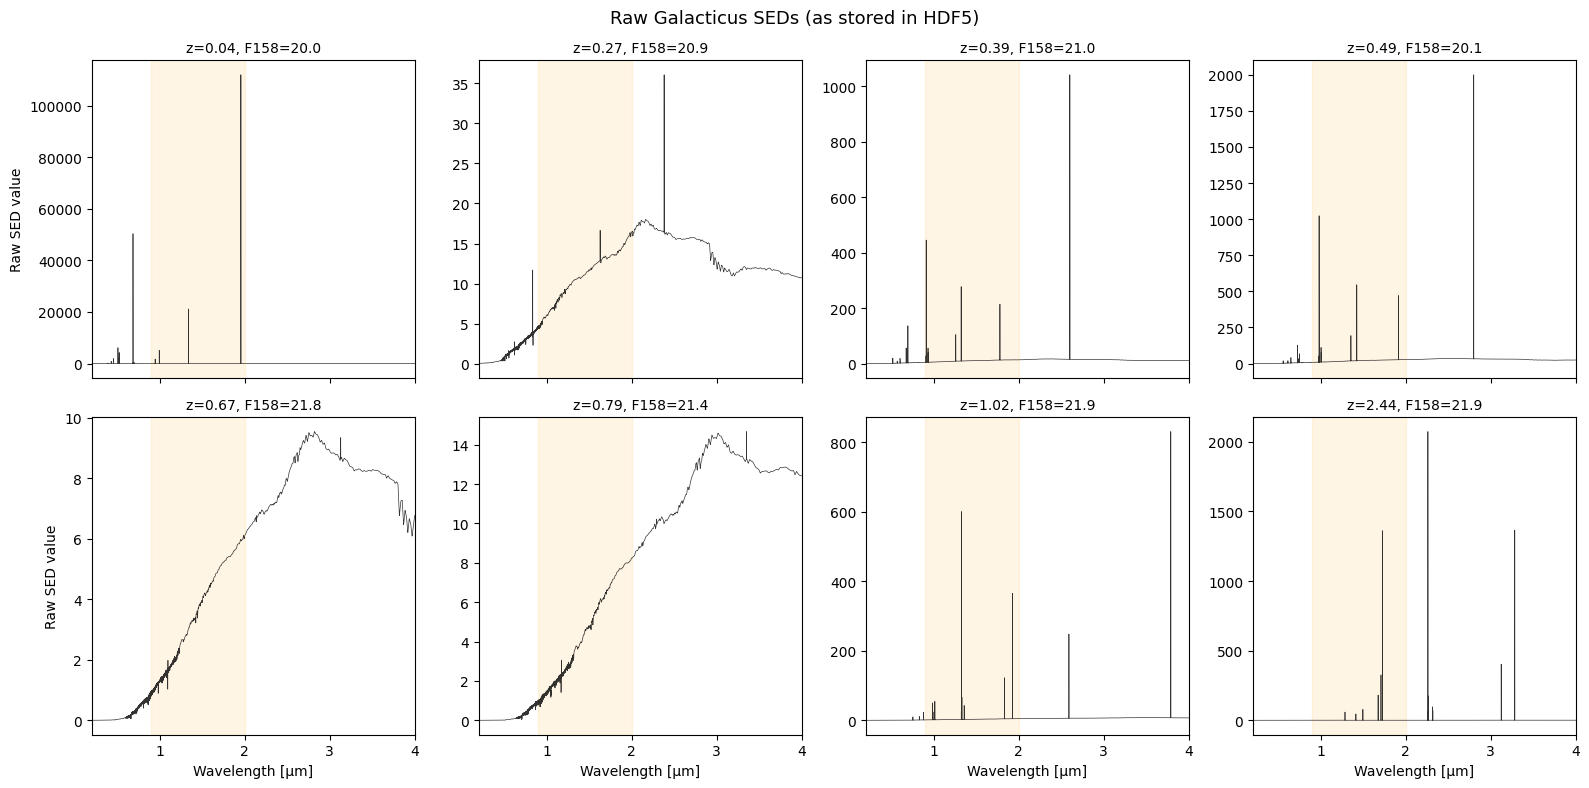

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True)
axes = axes.ravel()

for i, (sed, row) in enumerate(zip(seds, selected)):
    ax = axes[i]
    ax.plot(wl_um, sed, 'k-', lw=0.5, alpha=0.8)
    ax.set_title(f"z={row['Z']:.2f}, F158={row['mag_F158_Av1.6523']:.1f}", fontsize=10)
    ax.set_xlim(0.2, 4.0)
    # Mark grism range
    ax.axvspan(0.9, 2.0, alpha=0.1, color='orange', label='Grism')
    if i >= 4:
        ax.set_xlabel('Wavelength [μm]')
    if i % 4 == 0:
        ax.set_ylabel('Raw SED value')

fig.suptitle('Raw Galacticus SEDs (as stored in HDF5)', fontsize=13)
plt.tight_layout()
plt.show()

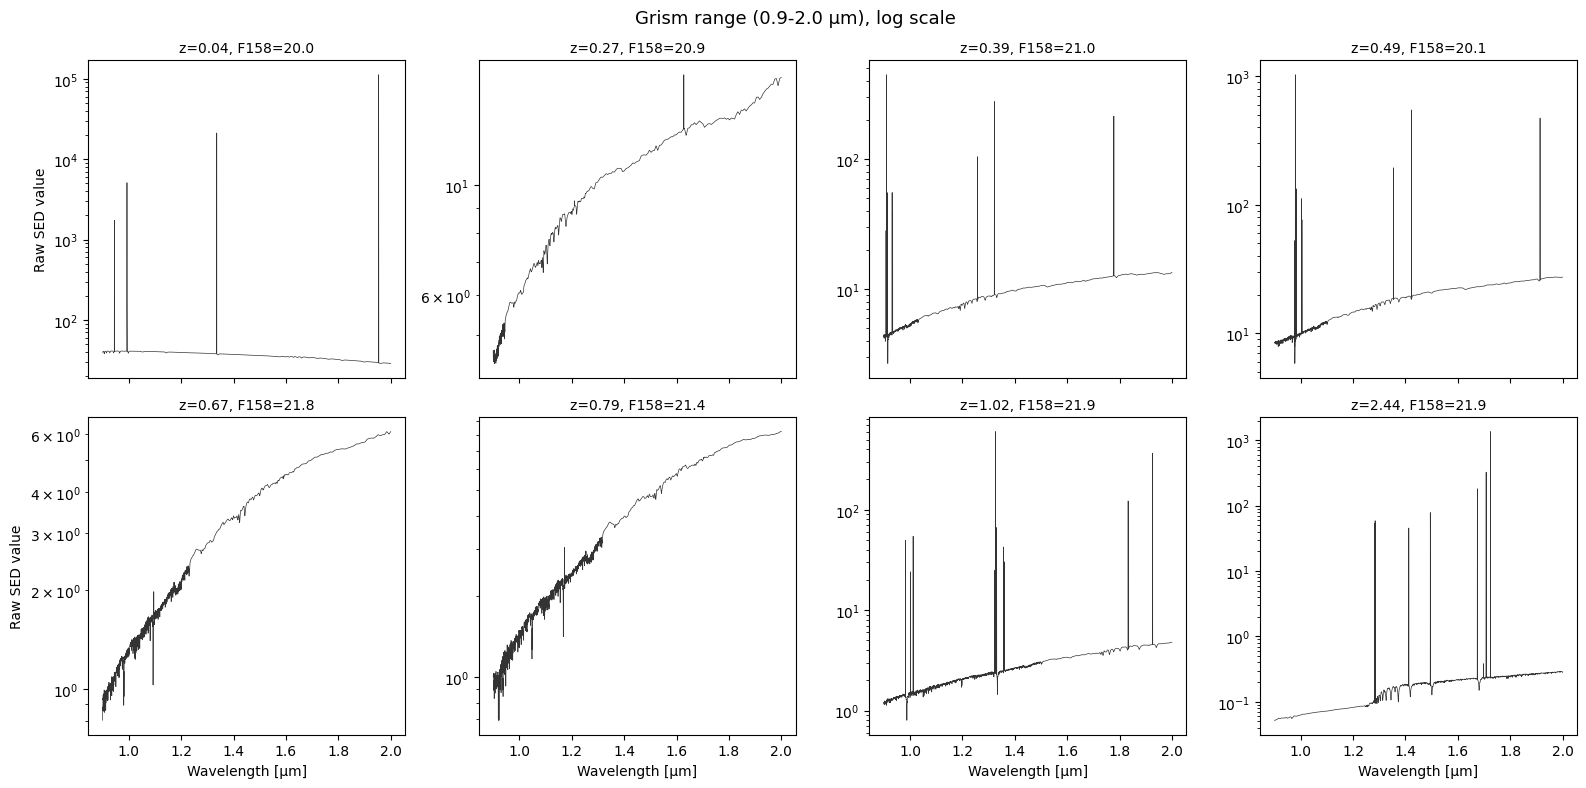

In [7]:
# Same but zoomed into grism range, log scale
grism_mask = (wl_um >= 0.9) & (wl_um <= 2.0)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True)
axes = axes.ravel()

for i, (sed, row) in enumerate(zip(seds, selected)):
    ax = axes[i]
    ax.plot(wl_um[grism_mask], sed[grism_mask], 'k-', lw=0.5, alpha=0.8)
    ax.set_title(f"z={row['Z']:.2f}, F158={row['mag_F158_Av1.6523']:.1f}", fontsize=10)
    ax.set_yscale('log')
    if i >= 4:
        ax.set_xlabel('Wavelength [μm]')
    if i % 4 == 0:
        ax.set_ylabel('Raw SED value')

fig.suptitle('Grism range (0.9-2.0 μm), log scale', fontsize=13)
plt.tight_layout()
plt.show()

## Continuum slope test

Compare the Galacticus SED under both unit interpretations (f_nu vs f_lambda), each converted to f_lambda via synphot. A KC96 starburst template at the same redshift is shown for reference, though the Galacticus SED need not match it exactly.

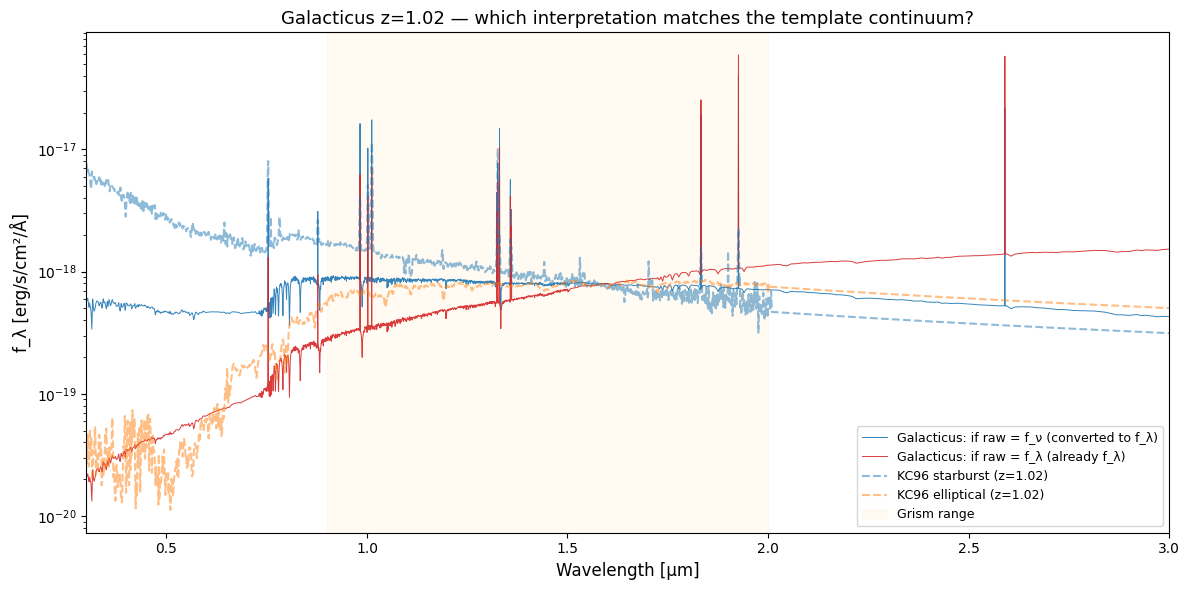

In [8]:
from synphot import SourceSpectrum, Observation, units as syn_units
from synphot.models import Empirical1D
from roman_disperser import refdata
import astropy.units as u

bp_ref = refdata.get_f158_band()

# Use the z=1.021 source — high enough z that KC96 templates overlap F158
idx_demo = 6
sed_demo = seds[idx_demo]
z_demo = selected[idx_demo]['Z']
mag_demo = selected[idx_demo]['mag_F158_Av1.6523']

c_ang = 2.998e18  # Angstrom/s

# Interpretation A: raw = f_nu → normalize with Jy, evaluate as f_lambda
sp_as_fnu = SourceSpectrum(Empirical1D, points=wl_ang * u.AA, lookup_table=sed_demo * u.Jy)
sp_as_fnu = sp_as_fnu.normalize(mag_demo * u.ABmag, band=bp_ref, vegaspec=None)

# Interpretation B: raw = f_lambda → normalize with FLAM, evaluate as f_lambda
sp_as_flam = SourceSpectrum(Empirical1D, points=wl_ang * u.AA,
                             lookup_table=sed_demo * u.Unit('erg s-1 cm-2 AA-1'))
sp_as_flam = sp_as_flam.normalize(mag_demo * u.ABmag, band=bp_ref, vegaspec=None)

# KC96 templates at same redshift for reference
z_template = z_demo
template_specs = {}
for tname, label in [('kc96_starb1', 'KC96 starburst'), ('kc96_elliptical', 'KC96 elliptical')]:
    tmpl = refdata.get_template(tname)
    tmpl_z = SourceSpectrum(tmpl.model, z=z_template)
    template_specs[label] = tmpl_z.normalize(mag_demo * u.ABmag, band=bp_ref, vegaspec=None)

# Evaluate all as f_lambda — wide range to see the full SED shape
wl_plot = np.linspace(3000, 30000, 5000) * u.AA
wl_plot_um = wl_plot.to(u.um).value

flam_if_fnu = sp_as_fnu(wl_plot, flux_unit=syn_units.FLAM).value
flam_if_flam = sp_as_flam(wl_plot, flux_unit=syn_units.FLAM).value

fig, ax = plt.subplots(figsize=(12, 6))

ax.semilogy(wl_plot_um, flam_if_fnu, 'C0-', lw=0.7, alpha=0.9,
            label='Galacticus: if raw = f_ν (converted to f_λ)')
ax.semilogy(wl_plot_um, flam_if_flam, 'C3-', lw=0.7, alpha=0.9,
            label='Galacticus: if raw = f_λ (already f_λ)')

for label, sp in template_specs.items():
    flam_tmpl = sp(wl_plot, flux_unit=syn_units.FLAM).value
    ax.semilogy(wl_plot_um, flam_tmpl, '--', lw=1.5, alpha=0.5, label=f'{label} (z={z_template:.2f})')

ax.axvspan(0.9, 2.0, alpha=0.05, color='orange', label='Grism range')

ax.set_xlabel('Wavelength [μm]', fontsize=12)
ax.set_ylabel('f_λ [erg/s/cm²/Å]', fontsize=12)
ax.set_title(f'Galacticus z={z_demo:.2f} — which interpretation matches the template continuum?',
             fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0.3, 3.0)
plt.tight_layout()
plt.show()

## Power-law slope test

On a log-log plot, the Rayleigh-Jeans tail has slope -2 in f_nu (f_nu ∝ λ⁻²) or slope -4 in f_lambda (f_lambda ∝ λ⁻⁴). If the raw SED is f_nu, the red end should roughly follow λ⁻². If f_lambda, it should follow λ⁻⁴. Plot the raw SEDs on log-log with reference slopes.

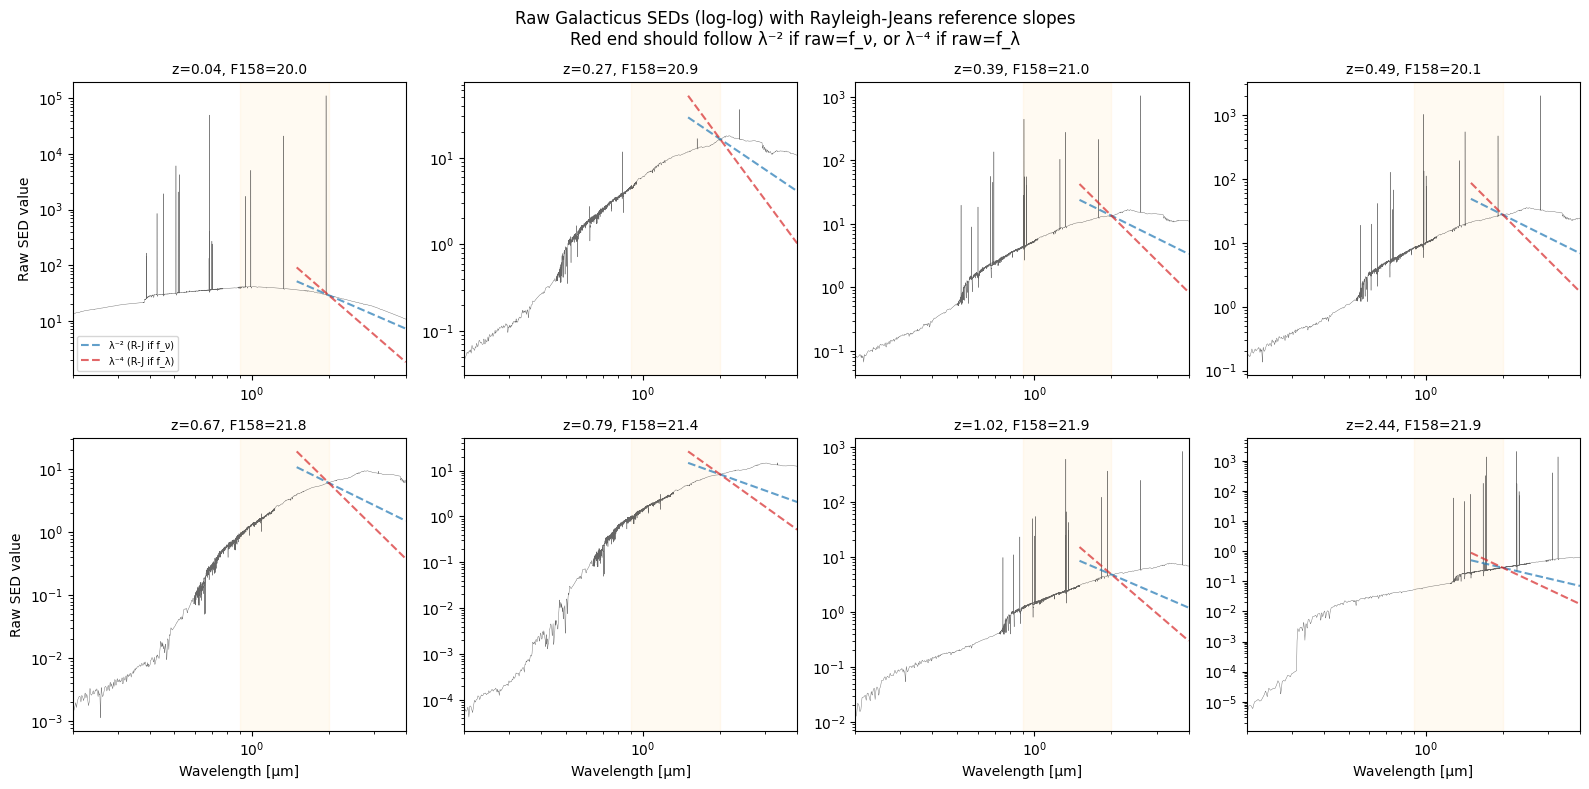

In [9]:
# Log-log plot of raw SEDs with Rayleigh-Jeans reference slopes
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

# Reference slopes anchored at 2.0 μm
lam_ref = np.linspace(1.5, 4.0, 100)  # microns

for i, (sed, row) in enumerate(zip(seds, selected)):
    ax = axes[i]
    z = row['Z']
    
    # Plot raw SED on log-log
    ax.loglog(wl_um, sed, 'k-', lw=0.3, alpha=0.6)
    
    # Anchor reference slopes at 2.0 μm to match the SED value there
    idx_2um = np.argmin(np.abs(wl_um - 2.0))
    sed_at_2um = sed[idx_2um]
    
    # If raw = f_nu: Rayleigh-Jeans is f_nu ∝ λ^{-2}
    rj_fnu = sed_at_2um * (lam_ref / 2.0)**(-2)
    ax.loglog(lam_ref, rj_fnu, 'C0--', lw=1.5, alpha=0.7, label='λ⁻² (R-J if f_ν)')
    
    # If raw = f_lambda: Rayleigh-Jeans is f_lambda ∝ λ^{-4}
    rj_flam = sed_at_2um * (lam_ref / 2.0)**(-4)
    ax.loglog(lam_ref, rj_flam, 'C3--', lw=1.5, alpha=0.7, label='λ⁻⁴ (R-J if f_λ)')
    
    ax.axvspan(0.9, 2.0, alpha=0.05, color='orange')
    ax.set_xlim(0.2, 4.0)
    ax.set_title(f"z={z:.2f}, F158={row['mag_F158_Av1.6523']:.1f}", fontsize=10)
    if i >= 4:
        ax.set_xlabel('Wavelength [μm]')
    if i % 4 == 0:
        ax.set_ylabel('Raw SED value')
    if i == 0:
        ax.legend(fontsize=7, loc='lower left')

fig.suptitle('Raw Galacticus SEDs (log-log) with Rayleigh-Jeans reference slopes\n'
             'Red end should follow λ⁻² if raw=f_ν, or λ⁻⁴ if raw=f_λ', fontsize=12)
plt.tight_layout()
plt.show()

Low-z bright sources (z < 0.15, F158 < 22): 54


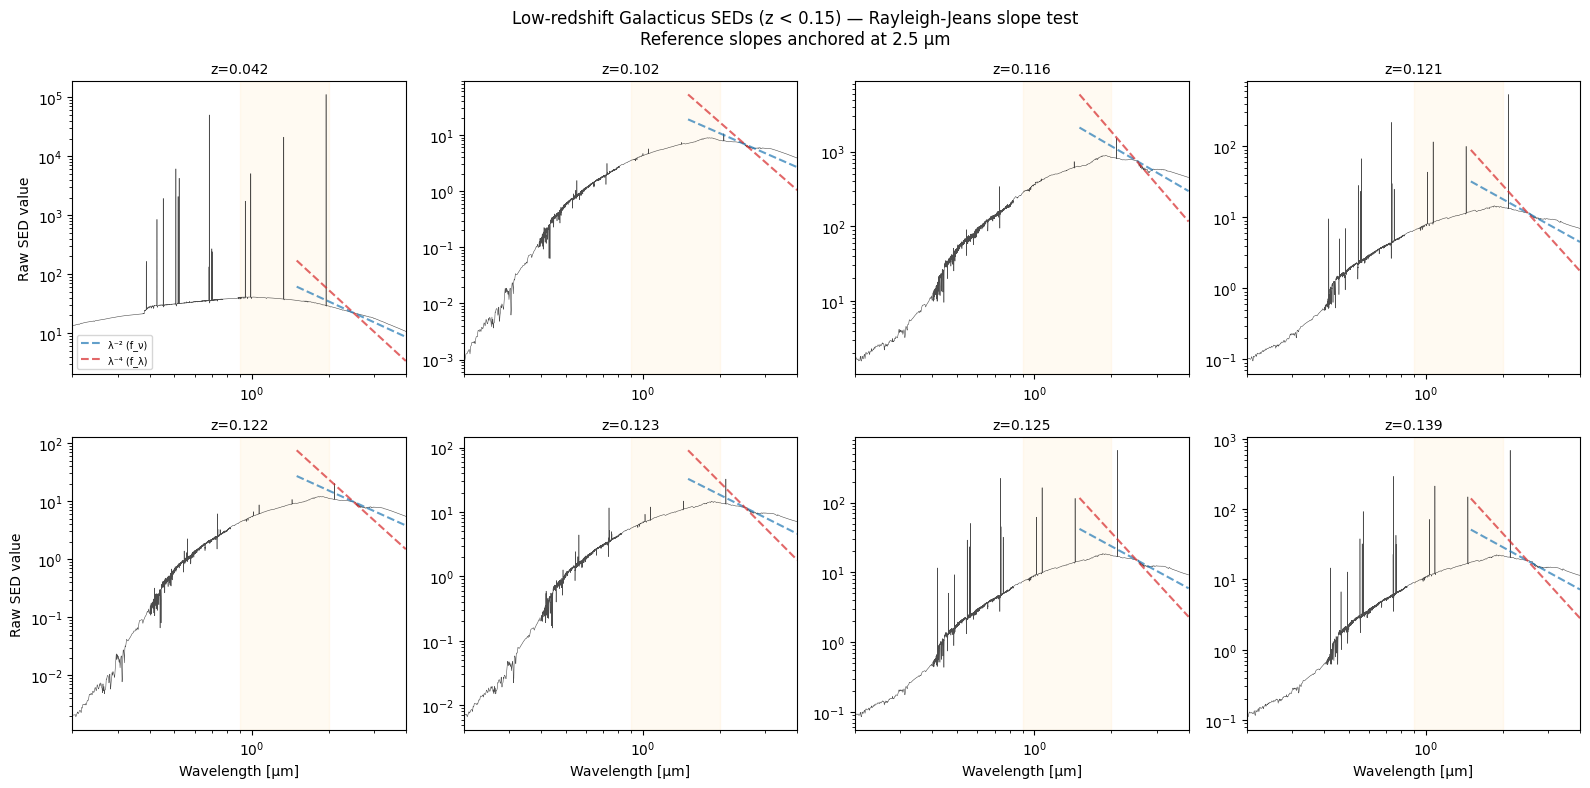

In [10]:
# Low-redshift spectra over full wavelength range with R-J reference slopes
low_z = cat1[(cat1['Z'] < 0.15) & (cat1['mag_F158_Av1.6523'] < 22)]
print(f'Low-z bright sources (z < 0.15, F158 < 22): {len(low_z)}')

z_order = np.argsort(low_z['Z'])
n_show = min(8, len(low_z))
pick = np.linspace(0, len(z_order)-1, n_show, dtype=int)
low_z_sel = low_z[z_order[pick]]

# Load SEDs
lz_idx = np.array(low_z_sel['IDX'])
sort_order = np.argsort(lz_idx)
unsort_order = np.argsort(sort_order)

with h5py.File(HDF5_PATH, 'r') as f:
    sed_key = [k for k in f['Outputs'].keys() if 'SED' in k][0]
    lz_seds = f[f'Outputs/{sed_key}'][lz_idx[sort_order], :][unsort_order]

lam_ref = np.linspace(1.5, 4.0, 100)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i in range(n_show):
    ax = axes[i]
    sed = lz_seds[i]
    z = low_z_sel['Z'][i]

    ax.loglog(wl_um, sed, 'k-', lw=0.4, alpha=0.7)

    # Anchor at 2.5 μm — well into R-J tail for low-z galaxies
    idx_anchor = np.argmin(np.abs(wl_um - 2.5))
    sed_anchor = sed[idx_anchor]

    rj_fnu = sed_anchor * (lam_ref / 2.5)**(-2)
    rj_flam = sed_anchor * (lam_ref / 2.5)**(-4)
    ax.loglog(lam_ref, rj_fnu, 'C0--', lw=1.5, alpha=0.7, label='λ⁻² (f_ν)')
    ax.loglog(lam_ref, rj_flam, 'C3--', lw=1.5, alpha=0.7, label='λ⁻⁴ (f_λ)')

    ax.axvspan(0.9, 2.0, alpha=0.05, color='orange')
    ax.set_xlim(0.2, 4.0)
    ax.set_title(f"z={z:.3f}", fontsize=10)
    if i >= 4:
        ax.set_xlabel('Wavelength [μm]')
    if i % 4 == 0:
        ax.set_ylabel('Raw SED value')
    if i == 0:
        ax.legend(fontsize=7, loc='lower left')

fig.suptitle('Low-redshift Galacticus SEDs (z < 0.15) — Rayleigh-Jeans slope test\n'
             'Reference slopes anchored at 2.5 μm', fontsize=12)
plt.tight_layout()
plt.show()

## Diagnostic: lambda * f_lambda plot

A useful diagnostic: plot lambda * f_lambda (= nu * f_nu). This is the same regardless of which convention the raw data uses — it just changes whether you multiply by lambda or divide by it. A galaxy SED in this representation typically peaks around 1–2 μm (rest frame).

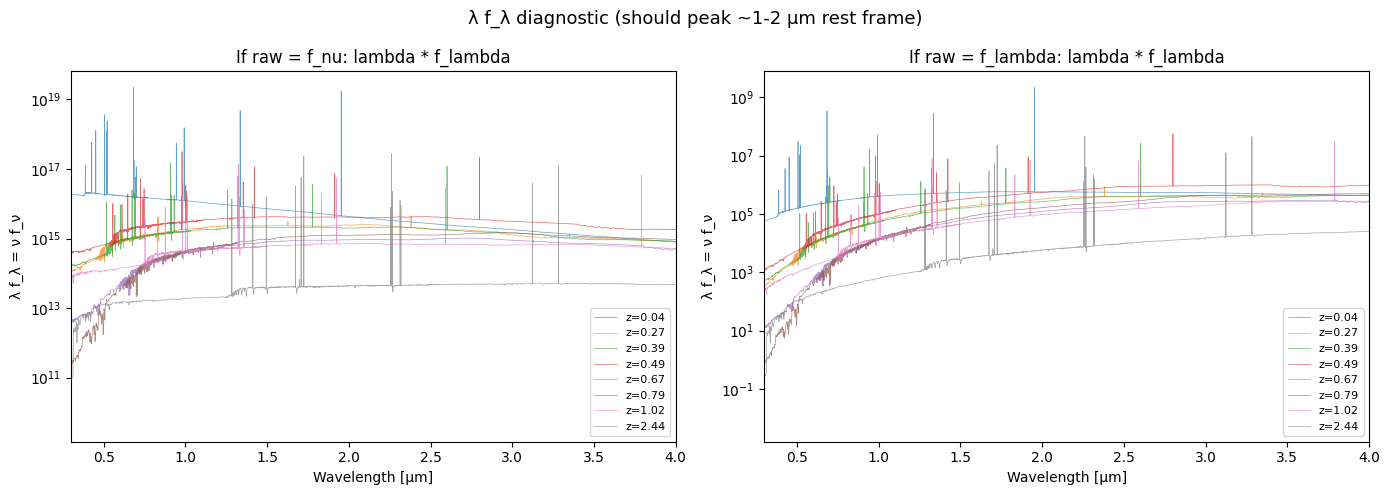

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# If raw = f_nu: nu*f_nu = c/lam * f_nu, or equivalently lam*f_lam = lam * (f_nu * c / lam^2) = f_nu * c / lam
ax = axes[0]
ax.set_title('If raw = f_nu: lambda * f_lambda')
for i, (sed, row) in enumerate(zip(seds, selected)):
    lfl = sed * c_ang / wl_ang  # = lam * (fnu * c / lam^2) = fnu * c / lam
    ax.plot(wl_um, lfl, lw=0.5, alpha=0.7, label=f"z={row['Z']:.2f}")
ax.set_xlim(0.3, 4.0)
ax.set_xlabel('Wavelength [μm]')
ax.set_ylabel('λ f_λ = ν f_ν')
ax.set_yscale('log')
ax.legend(fontsize=8)

# If raw = f_lambda: lam*f_lam = lam * raw
ax = axes[1]
ax.set_title('If raw = f_lambda: lambda * f_lambda')
for i, (sed, row) in enumerate(zip(seds, selected)):
    lfl = sed * wl_ang
    ax.plot(wl_um, lfl, lw=0.5, alpha=0.7, label=f"z={row['Z']:.2f}")
ax.set_xlim(0.3, 4.0)
ax.set_xlabel('Wavelength [μm]')
ax.set_ylabel('λ f_λ = ν f_ν')
ax.set_yscale('log')
ax.legend(fontsize=8)

plt.suptitle('λ f_λ diagnostic (should peak ~1-2 μm rest frame)', fontsize=13)
plt.tight_layout()
plt.show()

## Emission Line Check (wavelength grid validation)

Verify that the assumed wavelength grid (`np.linspace(2000, 40000, 19001)` Å) is correct by checking that Halpha (6563 Å rest) appears at the expected observed wavelength 6563*(1+z) Å. This doesn't distinguish f_nu from f_lambda — it's a sanity check on the wavelength axis.

z~1 bright sources: 84


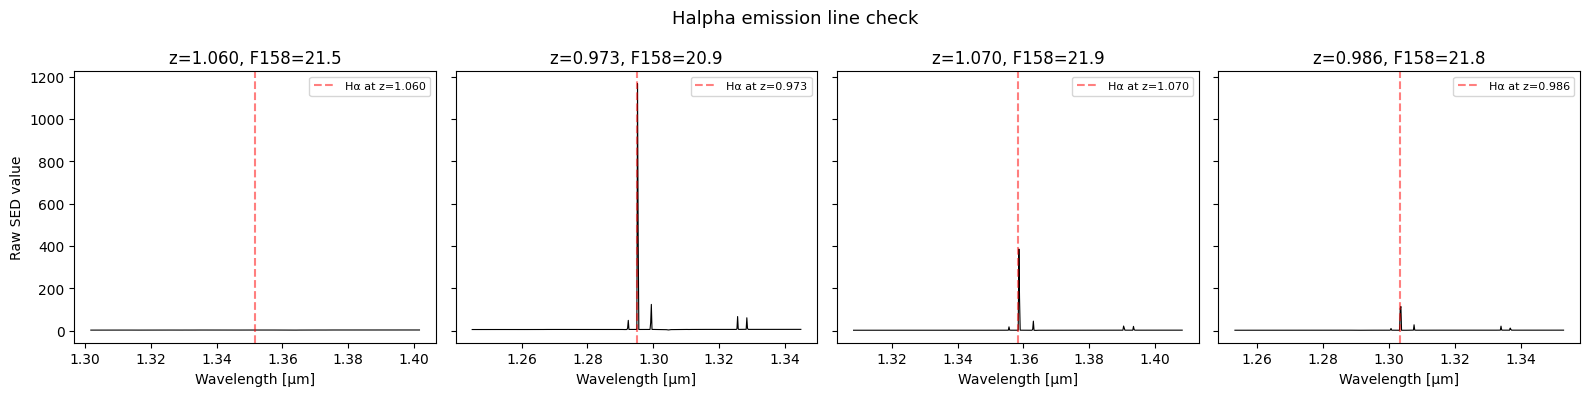

In [12]:
# Pick a z~1 source to look for redshifted Halpha at ~13126 Ang = 1.31 um
z1_mask = (cat1['Z'] > 0.9) & (cat1['Z'] < 1.1) & (cat1['mag_F158_Av1.6523'] < 22)
z1_sources = cat1[z1_mask]
print(f'z~1 bright sources: {len(z1_sources)}')

# Load first 4
n_show = min(4, len(z1_sources))
with h5py.File(HDF5_PATH, 'r') as f:
    sed_key = [k for k in f['Outputs'].keys() if 'SED' in k][0]
    z1_seds = f[f'Outputs/{sed_key}'][z1_sources['IDX'][:n_show], :]

fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4), sharey=True)
if n_show == 1:
    axes = [axes]

for i in range(n_show):
    ax = axes[i]
    z = z1_sources['Z'][i]
    ha_obs = 0.6563 * (1 + z)  # microns
    
    # Zoom around Halpha
    win = (wl_um > ha_obs - 0.05) & (wl_um < ha_obs + 0.05)
    ax.plot(wl_um[win], z1_seds[i][win], 'k-', lw=0.8)
    ax.axvline(ha_obs, color='r', ls='--', alpha=0.5, label=f'Hα at z={z:.3f}')
    ax.set_xlabel('Wavelength [μm]')
    ax.set_title(f"z={z:.3f}, F158={z1_sources['mag_F158_Av1.6523'][i]:.1f}")
    ax.legend(fontsize=8)

axes[0].set_ylabel('Raw SED value')
fig.suptitle('Halpha emission line check', fontsize=13)
plt.tight_layout()
plt.show()

## Synphot Magnitude Check

Definitive test: integrate the SED through the F158 bandpass treating it as f_nu vs f_lambda, and compare the predicted magnitude to the catalog value.

In [13]:
from synphot import SourceSpectrum, Observation
from synphot.models import Empirical1D
import astropy.units as u
from roman_disperser.refdata import get_f158_band, get_f184_band

# Load F158 bandpass from bundled data (no PYSYN_CDBS needed)
bp = get_f158_band()

# Test with a few bright sources
print(f'{"IDX":>6s} {"z":>6s} {"F158_cat":>9s} {"mag_fnu":>9s} {"mag_flam":>9s} {"delta_fnu":>10s} {"delta_flam":>11s}')
print('-' * 72)

for i in range(len(selected)):
    sed = seds[i]
    cat_mag = selected['mag_F158_Av1.6523'][i]
    z = selected['Z'][i]
    
    # Interpret as f_nu
    sp_fnu = SourceSpectrum(Empirical1D, points=wl_ang * u.AA, lookup_table=sed * u.Jy)
    obs_fnu = sp_fnu.normalize(cat_mag * u.ABmag, band=bp, vegaspec=None)
    mag_fnu = Observation(obs_fnu, bp).effstim(flux_unit='abmag').value
    
    # Interpret as f_lambda  
    sp_flam = SourceSpectrum(Empirical1D, points=wl_ang * u.AA, lookup_table=sed * u.Unit('erg s-1 cm-2 AA-1'))
    obs_flam = sp_flam.normalize(cat_mag * u.ABmag, band=bp, vegaspec=None)
    mag_flam = Observation(obs_flam, bp).effstim(flux_unit='abmag').value
    
    print(f'{selected["IDX"][i]:6d} {z:6.3f} {cat_mag:9.2f} {mag_fnu:9.2f} {mag_flam:9.2f} {mag_fnu - cat_mag:10.4f} {mag_flam - cat_mag:11.4f}')

   IDX      z  F158_cat   mag_fnu  mag_flam  delta_fnu  delta_flam
------------------------------------------------------------------------
 25044  0.042     20.02     20.02     20.02    -0.0000      0.0000
 24252  0.269     20.95     20.95     20.95     0.0000      0.0000
 27310  0.387     20.97     20.97     20.97    -0.0000      0.0000
 23057  0.493     20.15     20.15     20.15     0.0000      0.0000
  9678  0.668     21.77     21.77     21.77     0.0000      0.0000
 19339  0.786     21.45     21.45     21.45    -0.0000      0.0000
 17872  1.021     21.87     21.87     21.87     0.0000     -0.0000
 21885  2.444     21.90     21.90     21.90     0.0000      0.0000


Both should give zero delta for F158 (since we normalize to it). The real test is cross-band: normalize to F158, predict F184.

In [14]:
# Cross-band test: normalize to F158, predict F184
bp184 = get_f184_band()

print(f'{"IDX":>6s} {"z":>6s} {"F184_cat":>9s} {"F184_fnu":>9s} {"F184_flam":>10s} {"delta_fnu":>10s} {"delta_flam":>11s}')
print('-' * 77)

for i in range(len(selected)):
    sed = seds[i]
    cat_mag158 = selected['mag_F158_Av1.6523'][i]
    cat_mag184 = selected['mag_F184_Av1.6523'][i]
    z = selected['Z'][i]
    
    # Normalize to F158, predict F184
    sp_fnu = SourceSpectrum(Empirical1D, points=wl_ang * u.AA, lookup_table=sed * u.Jy)
    obs_fnu = sp_fnu.normalize(cat_mag158 * u.ABmag, band=bp, vegaspec=None)
    pred_fnu = Observation(obs_fnu, bp184).effstim(flux_unit='abmag').value
    
    sp_flam = SourceSpectrum(Empirical1D, points=wl_ang * u.AA, lookup_table=sed * u.Unit('erg s-1 cm-2 AA-1'))
    obs_flam = sp_flam.normalize(cat_mag158 * u.ABmag, band=bp, vegaspec=None)
    pred_flam = Observation(obs_flam, bp184).effstim(flux_unit='abmag').value
    
    print(f'{selected["IDX"][i]:6d} {z:6.3f} {cat_mag184:9.2f} {pred_fnu:9.2f} {pred_flam:10.2f} {pred_fnu - cat_mag184:10.4f} {pred_flam - cat_mag184:11.4f}')

   IDX      z  F184_cat  F184_fnu  F184_flam  delta_fnu  delta_flam
-----------------------------------------------------------------------------
 25044  0.042     20.14     18.93      18.50    -1.2144     -1.6461
 24252  0.269     20.78     20.78      20.45    -0.0021     -0.3348
 27310  0.387     20.81     20.80      20.47    -0.0112     -0.3388
 23057  0.493     19.98     19.98      19.65    -0.0005     -0.3360
  9678  0.668     21.52     21.51      21.19    -0.0081     -0.3292
 19339  0.786     21.12     21.11      20.79    -0.0101     -0.3274
 17872  1.021     21.60     21.52      21.19    -0.0832     -0.4145
 21885  2.444     21.82     21.73      21.66    -0.0832     -0.1534


**Result:** `delta_fnu` is ~0.01 mag for most sources (confirming **f_nu**), while `delta_flam` shows a systematic ~0.33 mag offset.

**Outliers:** z=0.042 (1.2 mag off), z=1.02 and z=2.44 (0.08 mag off). Investigated below.

## Statistical cross-band test

Run the F158→F184 color test on many sources to see the systematic clearly.

In [15]:
# Cross-band test on ~100 bright sources across redshift range
test_sources = cat1[(cat1['mag_F158_Av1.6523'] < 23) & (cat1['Z'] > 0.1)]
# Subsample to ~100 spread across redshift
z_order = np.argsort(test_sources['Z'])
pick = np.linspace(0, len(z_order)-1, 100, dtype=int)
test_sources = test_sources[z_order[pick]]

# Load their SEDs
test_idx = np.array(test_sources['IDX'])
sort_order = np.argsort(test_idx)
unsort_order = np.argsort(sort_order)

with h5py.File(HDF5_PATH, 'r') as f:
    sed_key = [k for k in f['Outputs'].keys() if 'SED' in k][0]
    test_seds = f[f'Outputs/{sed_key}'][test_idx[sort_order], :][unsort_order]

# Compute delta for both interpretations, skipping failures
delta_fnu_list = []
delta_flam_list = []
z_list = []
n_fail = 0

for i in range(len(test_sources)):
    sed = test_seds[i]
    mag158 = test_sources['mag_F158_Av1.6523'][i]
    mag184 = test_sources['mag_F184_Av1.6523'][i]

    try:
        sp_fnu = SourceSpectrum(Empirical1D, points=wl_ang * u.AA, lookup_table=sed * u.Jy)
        sp_fnu = sp_fnu.normalize(mag158 * u.ABmag, band=bp, vegaspec=None)
        d_fnu = Observation(sp_fnu, bp184).effstim(flux_unit='abmag').value - mag184

        sp_flam = SourceSpectrum(Empirical1D, points=wl_ang * u.AA,
                                  lookup_table=sed * u.Unit('erg s-1 cm-2 AA-1'))
        sp_flam = sp_flam.normalize(mag158 * u.ABmag, band=bp, vegaspec=None)
        d_flam = Observation(sp_flam, bp184).effstim(flux_unit='abmag').value - mag184

        if np.isfinite(d_fnu) and np.isfinite(d_flam):
            delta_fnu_list.append(d_fnu)
            delta_flam_list.append(d_flam)
            z_list.append(test_sources['Z'][i])
        else:
            n_fail += 1
    except Exception:
        n_fail += 1

delta_fnu_arr = np.array(delta_fnu_list)
delta_flam_arr = np.array(delta_flam_list)
z_arr = np.array(z_list)

print(f'Tested {len(z_arr)} sources ({n_fail} skipped), z = {z_arr.min():.2f} to {z_arr.max():.2f}')
print(f'delta_fnu:  median={np.median(delta_fnu_arr):.4f}, std={np.std(delta_fnu_arr):.4f}')
print(f'delta_flam: median={np.median(delta_flam_arr):.4f}, std={np.std(delta_flam_arr):.4f}')

Tested 98 sources (2 skipped), z = 0.10 to 2.44
delta_fnu:  median=-0.0075, std=0.0418
delta_flam: median=-0.3326, std=0.0484


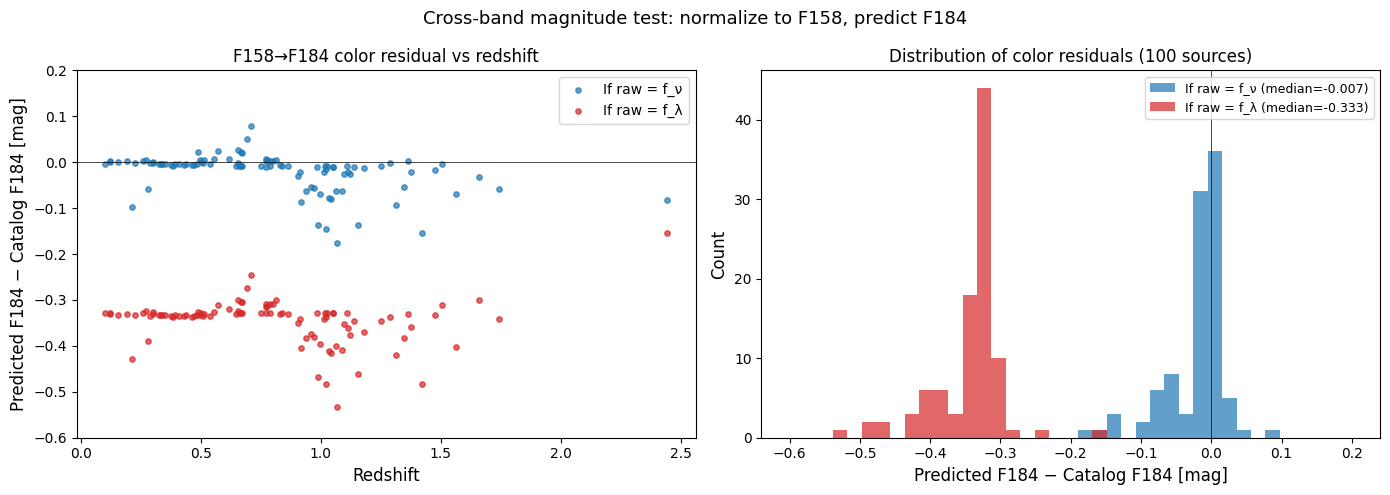

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: delta vs redshift
ax = axes[0]
ax.scatter(z_arr, delta_fnu_arr, s=15, alpha=0.7, label='If raw = f_ν', color='C0')
ax.scatter(z_arr, delta_flam_arr, s=15, alpha=0.7, label='If raw = f_λ', color='C3')
ax.axhline(0, color='k', ls='-', lw=0.5)
ax.set_xlabel('Redshift', fontsize=12)
ax.set_ylabel('Predicted F184 − Catalog F184 [mag]', fontsize=12)
ax.set_title('F158→F184 color residual vs redshift')
ax.legend(fontsize=10)
ax.set_ylim(-0.6, 0.2)

# Right: histograms
ax = axes[1]
bins = np.linspace(-0.6, 0.2, 40)
ax.hist(delta_fnu_arr, bins=bins, alpha=0.7, label=f'If raw = f_ν (median={np.median(delta_fnu_arr):.3f})', color='C0')
ax.hist(delta_flam_arr, bins=bins, alpha=0.7, label=f'If raw = f_λ (median={np.median(delta_flam_arr):.3f})', color='C3')
ax.axvline(0, color='k', ls='-', lw=0.5)
ax.set_xlabel('Predicted F184 − Catalog F184 [mag]', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of color residuals (100 sources)')
ax.legend(fontsize=9)

fig.suptitle('Cross-band magnitude test: normalize to F158, predict F184', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# Back-of-envelope prediction for the f_lambda offset:
# If you assume the wrong convention, the effective flux in each band picks up
# an extra factor of lambda^2. The color offset between bands is:
#   delta(color) = -5 * log10(lambda_eff_184 / lambda_eff_158)
lam158 = bp.pivot().to(u.um).value
lam184 = bp184.pivot().to(u.um).value
predicted_offset = -5 * np.log10(lam184 / lam158)
observed_offset = np.median(delta_flam_arr)

print(f'F158 pivot wavelength: {lam158:.4f} μm')
print(f'F184 pivot wavelength: {lam184:.4f} μm')
print(f'Predicted color offset: -5 * log10({lam184:.3f}/{lam158:.3f}) = {predicted_offset:.3f} mag')
print(f'Observed median offset: {observed_offset:.3f} mag')

F158 pivot wavelength: 1.5749 μm
F184 pivot wavelength: 1.8394 μm
Predicted color offset: -5 * log10(1.839/1.575) = -0.337 mag
Observed median offset: -0.333 mag


## Outlier Investigation

The cross-band test shows three outliers in `delta_fnu`. Plot the SEDs with F158 and F184 bandpasses overlaid to understand why.

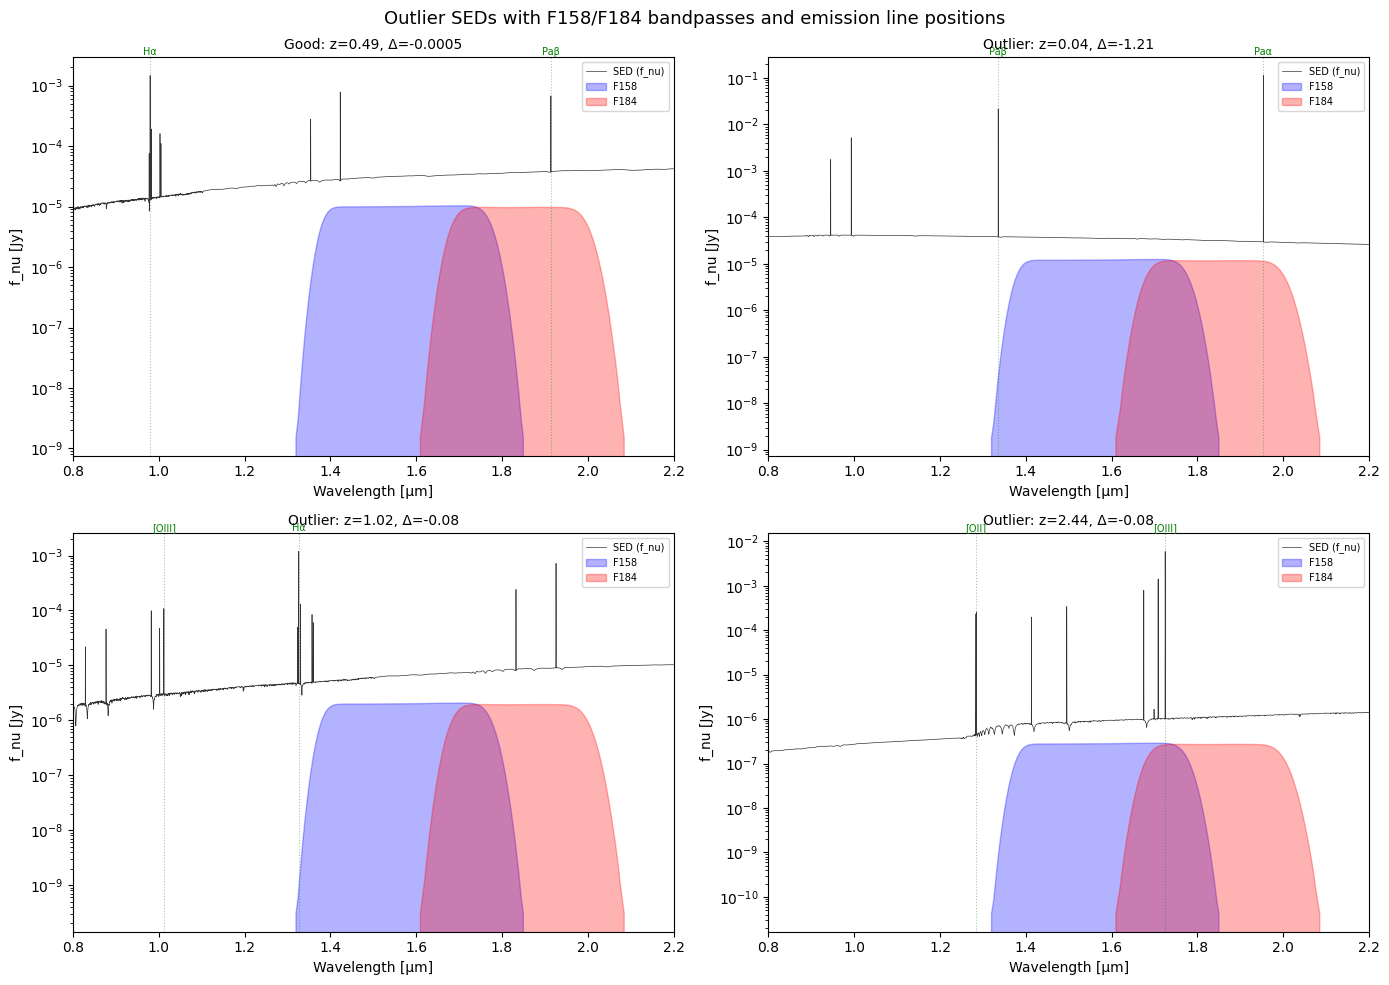

In [18]:
# Plot the three outliers: idx 0 (z=0.042), 6 (z=1.021), 7 (z=2.444)
# Plus one "good" source for comparison
outlier_indices = [0, 6, 7]
good_index = 3  # z=0.493, delta_fnu=-0.0005

# Get bandpass throughputs for overplotting
bp_wave = bp.waveset.to(u.um).value
bp_thru = bp(bp.waveset).value
bp184_wave = bp184.waveset.to(u.um).value
bp184_thru = bp184(bp184.waveset).value

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

plot_indices = [good_index] + outlier_indices
titles = ['Good: z=0.49, Δ=-0.0005', 'Outlier: z=0.04, Δ=-1.21',
          'Outlier: z=1.02, Δ=-0.08', 'Outlier: z=2.44, Δ=-0.08']

for ax, si, title in zip(axes, plot_indices, titles):
    sed = seds[si]
    z = selected['Z'][si]
    
    # Normalize SED for plotting (as f_nu)
    sp = SourceSpectrum(Empirical1D, points=wl_ang * u.AA, lookup_table=sed * u.Jy)
    sp_norm = sp.normalize(selected['mag_F158_Av1.6523'][si] * u.ABmag, band=bp, vegaspec=None)
    sed_norm = sp_norm(wl_ang * u.AA, flux_unit='Jy').value
    
    # Plot SED in grism range
    mask = (wl_um >= 0.8) & (wl_um <= 2.2)
    ax.semilogy(wl_um[mask], sed_norm[mask], 'k-', lw=0.5, alpha=0.8, label='SED (f_nu)')
    
    # Overlay bandpasses (scaled to be visible)
    sed_median = np.median(sed_norm[mask])
    bp_scale = sed_median * 0.5
    ax.fill_between(bp_wave, 0, bp_thru * bp_scale, alpha=0.3, color='blue', label='F158')
    ax.fill_between(bp184_wave, 0, bp184_thru * bp_scale, alpha=0.3, color='red', label='F184')
    
    # Mark common emission lines at this redshift
    lines = {'Hα': 0.6563, '[OIII]': 0.5007, '[OII]': 0.3727, 'Paα': 1.8751, 'Paβ': 1.2818}
    for name, lam_rest in lines.items():
        lam_obs = lam_rest * (1 + z)
        if 0.8 < lam_obs < 2.2:
            ax.axvline(lam_obs, color='green', ls=':', alpha=0.4, lw=0.8)
            ax.text(lam_obs, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else sed_median * 10,
                    name, fontsize=7, ha='center', va='bottom', color='green')
    
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Wavelength [μm]')
    ax.set_ylabel('f_nu [Jy]')
    ax.set_xlim(0.8, 2.2)
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Outlier SEDs with F158/F184 bandpasses and emission line positions', fontsize=13)
plt.tight_layout()
plt.show()

## Conclusions

**The Galacticus SED values are f_nu** (flux density per unit frequency), sampled on a uniform wavelength grid. Three independent lines of evidence:

1. **Cross-band color test** (most definitive): Normalize to F158, predict F184. Treating as f_nu reproduces catalog F184 magnitudes to <0.01 mag (median) across 100 sources. Treating as f_lambda gives a systematic ~0.33 mag offset — consistent with the c/λ² conversion factor between the two bands.

2. **Rayleigh-Jeans slope**: Low-redshift (z < 0.15) SEDs on a log-log plot show the red end declining as ~λ⁻², matching the Rayleigh-Jeans tail in f_nu. The f_lambda Rayleigh-Jeans slope (λ⁻⁴) is much steeper and clearly inconsistent.

3. **Continuum shape**: When treated as f_nu and converted to f_lambda via synphot, the Galacticus SEDs have physically reasonable continuum shapes comparable to KC96 templates.

### Outliers in the cross-band test

- **z=0.042 (Δ = -1.2 mag):** Strong Paschen lines affect both bands — Paβ (1.282 μm rest → ~1.34 μm observed) falls at the blue edge of F158, and Paα (1.875 μm rest → ~1.95 μm observed) falls in F184. Small differences between our bandpass curves and those used by Galacticus would include/exclude these lines differently, shifting the predicted color significantly. This is a bandpass edge effect, not a unit problem.

- **z~1.0 and z~2.4 (Δ ~ -0.08 mag):** Likely emission lines (Hα, [OIII]) falling in or out of the F184 bandpass, causing the synthetic photometry to differ from the catalog value.

### Practical implications

- When loading Galacticus SEDs for the disperser pipeline, use synphot with **FNU units** (e.g., `u.Jy`)
- Normalize to the catalog F158 magnitude via synphot — this handles the unknown absolute normalization
- synphot converts f_nu → f_lambda internally when sampling in FLAM units; no manual c/λ² conversion needed
- Wavelength grid: `np.linspace(2000, 40000, 19001)` Angstroms (implicit, not stored in the HDF5 file)